## 高斯系数

In [1]:
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import scipy.io as scio

def my_fft(a):
    k = np.fft.fft2(a)
    k = np.abs(k)
    k /= np.max(k)
    k = np.fft.fftshift(k)
    return k

def psnr(original_image, reconstructed_image):
    # 计算PSNR
    mse = np.mean((original_image - reconstructed_image) ** 2)
    psnr_value = 10 * np.log10((255 ** 2) / mse)
    return psnr_value

def calculate_metrics(original_image, reconstructed_images):
    ssim_scores = []
    psnr_scores = []

    for image in reconstructed_images:
        # 计算 SSIM
        ssim_value = ssim(original_image, image)
        ssim_scores.append(ssim_value)

        # 计算 PSNR
        psnr_value =  cv2.PSNR(original_image, image)
        psnr_scores.append(psnr_value)

    return ssim_scores, psnr_scores

def plot_metrics(ssim_scores, psnr_scores):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(ssim_scores)
    plt.title('SSIM')
    plt.xlabel('Index')
    plt.ylabel('SSIM Score')

    plt.subplot(1, 2, 2)
    plt.plot(psnr_scores)
    plt.title('PSNR')
    plt.xlabel('Index')
    plt.ylabel('PSNR Score')

    plt.show()

def find_best_image(reconstructed_images, ssim_scores, psnr_scores):
    best_index_ssim = np.argmax(ssim_scores)
    best_index_psnr = np.argmax(psnr_scores)

    best_image_ssim = reconstructed_images[best_index_ssim]
    best_image_psnr = reconstructed_images[best_index_psnr]

    return best_index_ssim, best_index_psnr

SSIM: 0.794
SSIM: 0.358


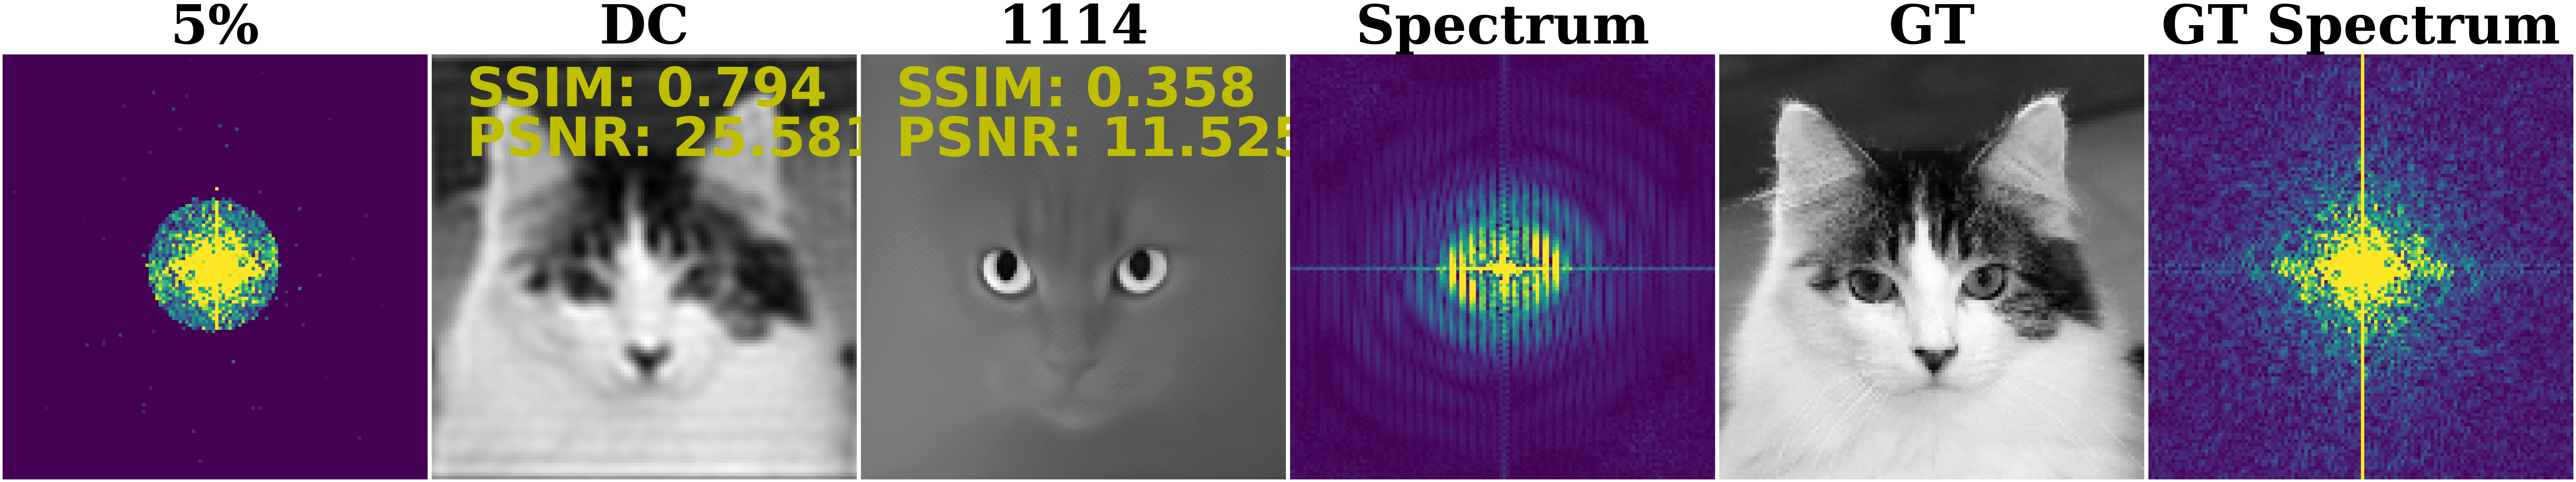

In [7]:
# 加载原始图片
img_size = 128
img_center = img_size // 2
original_image = cv2.imread('/home/a604/code/xzz/data/afhq/test/cat/flickr_cat_000008.jpg', cv2.IMREAD_GRAYSCALE)
# original_image = cv2.imread('/home/a604/code/xzz/data/ball/train/GT_401.png', cv2.IMREAD_GRAYSCALE)
original_image = cv2.resize(original_image, (img_size, img_size))
# original_image = cv2.imread('/home/a604/code/xzz/data/coin/train_dataset_raw/y/2385.bmp', cv2.IMREAD_GRAYSCALE)
# original_image = cv2.imread('/home/a604/code/xzz/data/coin/train_dataset_raw/y/2015.bmp', cv2.IMREAD_GRAYSCALE)
# 2385
# original_image = scio.loadmat("/home/b110/code1/xzz/data/coin/123.mat")['image_k']
# original_image = original_image.astype(np.float32) / np.max(original_image)
# 8 11 16 56 76 80 96 108
# original_image = np.fft.ifft2(original_image)
# original_image = np.float32(original_image)
# original_image = np.abs(original_image)
# original_image /= np.max(original_image)
i = 2
sample_rate = [1, 3, 5]
fnumb = '8_20_5'
Mask = scio.loadmat(f'/home/a604/code/xzz/ncsn_im/ncsnpp_ct_small_versioin2/mask/random_mask_{fnumb}.mat')['mask']
# mask_type = "random"
# Mask = scio.loadmat(f'/home/a604/code/xzz/ncsn/ncsnpp_ct_small_versioin2/mask/{mask_type}_mask_{sample_rate[i]}.mat')['mask']
# Mask = np.zeros((img_size, img_size))
# if i == 2: 
#     if img_size == 256:
#         Mask[img_center-28:img_center+28,img_center-28:img_center+28] = 1
#     else:    
#         Mask[img_center-14:img_center+14,img_center-14:img_center+14] = 1
# elif i == 1:
#     if img_size == 256:
#         Mask[img_center-22:img_center+22,img_center-22:img_center+22] = 1
#     else:
#         Mask[img_center-11:img_center+11,img_center-11:img_center+11] = 1
# else: 
#     if img_size == 256:
#         Mask[img_center-13:img_center+13,img_center-13:img_center+13] = 1
#     else:
#         Mask[img_center-7:img_center+7,img_center-7:img_center+7] = 1

fig, ax = plt.subplots(1, 6, figsize=(128, 128))

title_fontdict={'family': 'serif', 'weight': 'bold', 'size': 150}

# 加载重建图片并计算指标
reconstructed_images = []
for j in range(2000):
    ## freq 
    # reverse: 389 0.690  391 0.630  24 0.326
    # obverse: 1462 0.704  1550 0.644  1641 0.549
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/coin_weight/temp/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/coin_weight/simulate/obverse/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_temp/ncsnpp_ct_small_versioin2/reconstruct/cat/no_weight/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_temp/ncsnpp_ct_small_versioin2/reconstruct/cat/weight/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    ## img 
    # reverse: 1248 0.906  1630 0.850  1375 0.706
    # obverse: 1462 0.829  1176 0.789  1115 0.673
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_im_256/ncsnpp_ct_small_versioin2/reconstruct/temp/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_im/ncsnpp_ct_small_versioin2/reconstruct/coin/my/simulate/1/obverse/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_im/ncsnpp_ct_small_versioin2/reconstruct/cat/simulate/{img_size}/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    image = cv2.imread(f'reconstruct/cat/mask/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    ## hybrid 
    # reverse: 1240 0.902  1578 0.854  1592 0.717
    # obverse: 1628 0.826  1198 0.786  1121 0.682
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_hybrid/ncsnpp_ct_small_versioin2/reconstruct/coin/simulate/temp/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_hybrid/ncsnpp_ct_small_versioin2/reconstruct/coin/simulate/1/obverse/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_hybrid/ncsnpp_ct_small_versioin2/reconstruct/cat/simulate/1/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    ## freq2
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn2/ncsnpp_ct_small_versioin2/reconstruct/coin/simulate/temp/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn2/ncsnpp_ct_small_versioin2/reconstruct/cat/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    ## img2
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_im2/ncsnpp_ct_small_versioin2/reconstruct/coin/simulate/1/reverse/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = cv2.imread(f'/home/a604/code/xzz/ncsn_im2/ncsnpp_ct_small_versioin2/reconstruct/cat/simulate/1/{sample_rate[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = np.float32(image)
    # image = np.abs(image)
    # image /= np.max(image)
    reconstructed_images.append(image)
ssim_scores, psnr_scores = calculate_metrics(original_image, reconstructed_images)
# 绘制曲线图
# plot_metrics(ssim_scores, psnr_scores)
# 找出最好的图片
best_index_ssim, best_index_psnr = find_best_image(reconstructed_images, ssim_scores, psnr_scores)
# print(best_index_ssim)
dc_fft = np.fft.fft2(original_image)
dc_fft = np.fft.fftshift(dc_fft)
dc_fft = dc_fft * Mask
ax[0].imshow(np.abs(dc_fft), vmax=10000)
# ax[0].set_title(f'{fnumb[0:fnumb.find("_")]}%')
ax[0].set_title(f'{sample_rate[i]}%', fontdict=title_fontdict)
ax[0].axis('off')

# 保真的图像
dc_fft = np.fft.ifftshift(dc_fft)
dc_p = np.fft.ifft2(dc_fft)
dc_p = np.abs(dc_p)
# dc_p /= np.max(dc_p)
ssim_text = f'SSIM: {ssim(original_image, dc_p):.3f}'
psnr_text = f'PSNR: {psnr(original_image, dc_p):.3f}'
ax[1].text(10, 15, ssim_text, fontsize=150, color='y', fontdict={'weight':'bold'})
print(ssim_text)
ax[1].text(10, 30, psnr_text, fontsize=150, color='y', fontdict={'weight':'bold'})
ax[1].imshow(dc_p, cmap='gray')
ax[1].set_title(f'DC', fontdict=title_fontdict)
ax[1].axis('off')

# 在图像上标注SSIM和PSNR值
ssim_text = f'SSIM: {max(ssim_scores):.3f}'
psnr_text = f'PSNR: {max(psnr_scores):.3f}'
ax[2].text(10, 15, ssim_text, fontsize=150, color='y', fontdict={'weight':'bold'})
ax[2].text(10, 30, psnr_text, fontsize=150, color='y', fontdict={'weight':'bold'})
ax[2].imshow(reconstructed_images[best_index_ssim], cmap='gray')
ax[2].set_title(f"{best_index_ssim}", fontdict=title_fontdict)
print(ssim_text)
ax[2].axis('off')

ax[3].imshow(my_fft(reconstructed_images[best_index_ssim]), vmin=0, vmax=0.004)
ax[3].set_title("Spectrum", fontdict=title_fontdict)
ax[3].axis('off')

ax[4].imshow(original_image, cmap='gray')
ax[4].set_title("GT", fontdict=title_fontdict)
ax[4].axis('off')

ax[5].imshow(my_fft(original_image), vmin=0, vmax=0.004)
ax[5].set_title("GT Spectrum", fontdict=title_fontdict)
ax[5].axis('off')

# fig.suptitle(f'去除保真频谱的图像（第三行）与仅保留保真频谱的图像（第四行）')
# fig.suptitle(f'log2')
plt.subplots_adjust(top=0.90, wspace=0.01, hspace=0.4)
# plt.savefig(f'./result/tmp.jpg')

## 单行

(-0.5, 127.5, 127.5, -0.5)

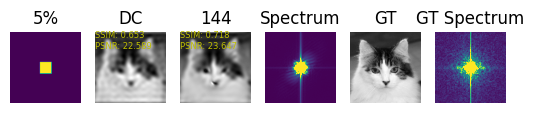

In [5]:
# 加载原始图片
# original_image = cv2.imread('/home/b110/code1/xzz/data/afhq/val/wild/flickr_wild_000521.jpg', cv2.IMREAD_GRAYSCALE)
original_image = cv2.imread('/home/b110/code1/xzz/data/afhq/val/cat/flickr_cat_000008.jpg', cv2.IMREAD_GRAYSCALE)
original_image = cv2.resize(original_image, (128, 128))
# original_image = np.float32(original_image)
# original_image = np.abs(original_image)
# original_image /= np.max(original_image)

# fnumb = '17_25_3'
# Mask = scio.loadmat(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/mask/random_mask_{fnumb}.mat')['mask']
Mask = np.zeros((128, 128))
# Mask[64-14:64+15,64-14:64+15] = 1
Mask[64-10:64+11,64-10:64+11] = 1
# Mask[64-5:64+6,64-5:64+6] = 1
fig, ax = plt.subplots(1, 6)

# 加载重建图片并计算指标
reconstructed_images = []
for j in range(2000):
    image = cv2.imread(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/3/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    # image = np.float32(image)
    # image = np.abs(image)
    # image /= np.max(image)
    reconstructed_images.append(image)
ssim_scores, psnr_scores = calculate_metrics(original_image, reconstructed_images)
# 绘制曲线图
# plot_metrics(ssim_scores, psnr_scores)
# 找出最好的图片
best_index_ssim, best_index_psnr = find_best_image(reconstructed_images, ssim_scores, psnr_scores)
# print(best_index_ssim)
ax[0].imshow(Mask)
# ax[0].set_title(f'{fnumb[0:fnumb.find("_")]}%')
ax[0].set_title(f'5%')
ax[0].axis('off')

# 保真的图像
dc_fft = np.fft.fft2(original_image)
dc_fft = np.fft.fftshift(dc_fft)
dc_fft = dc_fft * Mask
dc_fft = np.fft.ifftshift(dc_fft)
dc_p = np.fft.ifft2(dc_fft)
dc_p = np.abs(dc_p)
# dc_p /= np.max(dc_p)
ssim_text = f'SSIM: {ssim(original_image, dc_p):.3f}'
psnr_text = f'PSNR: {psnr(original_image, dc_p):.3f}'
ax[1].text(0, 10, ssim_text, fontsize=6, color='y')
ax[1].text(0, 30, psnr_text, fontsize=6, color='y')
ax[1].imshow(dc_p, cmap='gray')
ax[1].set_title(f'DC')
ax[1].axis('off')

# 在图像上标注SSIM和PSNR值
ssim_text = f'SSIM: {max(ssim_scores):.3f}'
psnr_text = f'PSNR: {max(psnr_scores):.3f}'
ax[2].text(0, 10, ssim_text, fontsize=6, color='y')
ax[2].text(0, 30, psnr_text, fontsize=6, color='y')
ax[2].imshow(reconstructed_images[best_index_ssim], cmap='gray')
ax[2].set_title(f"{best_index_ssim}")
ax[2].axis('off')

ax[3].imshow(my_fft(reconstructed_images[best_index_ssim]), vmin=0, vmax=0.004)
ax[3].set_title("Spectrum")
ax[3].axis('off')

ax[4].imshow(original_image, cmap='gray')
ax[4].set_title("GT")
ax[4].axis('off')

ax[5].imshow(my_fft(original_image), vmin=0, vmax=0.004)
ax[5].set_title("GT Spectrum")
ax[5].axis('off')

# fig.suptitle(f'去除保真频谱的图像（第三行）与仅保留保真频谱的图像（第四行）')
# fig.suptitle(f'log2')
# plt.subplots_adjust(top=0.90, wspace=0.01, hspace=0.4)
# plt.savefig(f'./result/tmp.jpg')

/home/b110/anaconda3/envs/xzz_ncsn/lib/python3.8/site-packages/skimage/_shared/utils.py:348: UserWarning: Inputs have mismatched dtype.  Setting data_range based on im1.dtype.
  return func(*args, **kwargs)


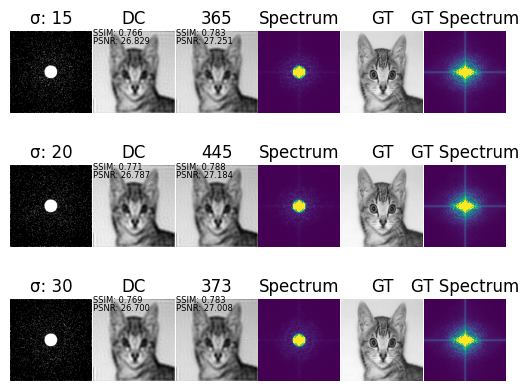

In [27]:
# 加载原始图片
original_image = cv2.imread('/home/b110/code1/xzz/data/cat/测试集1/resized_00001322_020.png', cv2.IMREAD_GRAYSCALE)
# original_image = np.float32(original_image)
# original_image = np.abs(original_image)
# original_image /= np.max(original_image)

nums = [15, 20, 30]
# nums = [1, 5, 10]

fig, ax = plt.subplots(len(nums), 6)

for i in range(len(nums)):
    Mask = scio.loadmat(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/mask/random_mask_5_20_{nums[i]}.mat')['mask']
    # 加载重建图片并计算指标
    reconstructed_images = []
    for j in range(2000):
        image = cv2.imread(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/cat5_20_{nums[i]}/{j}.bmp', cv2.IMREAD_GRAYSCALE)
        # image = np.float32(image)
        # image = np.abs(image)
        # image /= np.max(image)
        reconstructed_images.append(image)
    ssim_scores, psnr_scores = calculate_metrics(original_image, reconstructed_images)
    # 绘制曲线图
    # plot_metrics(ssim_scores, psnr_scores)
    # 找出最好的图片
    best_index_ssim, best_index_psnr = find_best_image(reconstructed_images, ssim_scores, psnr_scores)
    # print(best_index_ssim)
    ax[i][0].imshow(Mask, cmap='gray')
    ax[i][0].set_title(f'σ: {nums[i]}')
    ax[i][0].axis('off')

    # 保真的图像
    dc_fft = np.fft.fft2(original_image)
    dc_fft = np.fft.fftshift(dc_fft)
    dc_fft = dc_fft * Mask
    dc_fft = np.fft.ifftshift(dc_fft)
    dc_p = np.fft.ifft2(dc_fft)
    dc_p = np.abs(dc_p)
    # dc_p /= np.max(dc_p)
    ssim_text = f'SSIM: {ssim(original_image, dc_p):.3f}'
    psnr_text = f'PSNR: {psnr(original_image, dc_p):.3f}'
    ax[i][1].text(0, 10, ssim_text, fontsize=6)
    ax[i][1].text(0, 35, psnr_text, fontsize=6)
    ax[i][1].imshow(dc_p, cmap='gray')
    ax[i][1].set_title(f'DC')
    ax[i][1].axis('off')
    
    # 在图像上标注SSIM和PSNR值
    ssim_text = f'SSIM: {max(ssim_scores):.3f}'
    psnr_text = f'PSNR: {max(psnr_scores):.3f}'
    ax[i][2].text(0, 10, ssim_text, fontsize=6)
    ax[i][2].text(0, 35, psnr_text, fontsize=6)
    ax[i][2].imshow(reconstructed_images[best_index_ssim], cmap='gray')
    ax[i][2].set_title(f"{best_index_ssim}")
    ax[i][2].axis('off')

    ax[i][3].imshow(my_fft(reconstructed_images[best_index_ssim]), vmin=0, vmax=0.002)
    ax[i][3].set_title("Spectrum")
    ax[i][3].axis('off')

    ax[i][4].imshow(original_image, cmap='gray')
    ax[i][4].set_title("GT")
    ax[i][4].axis('off')

    ax[i][5].imshow(my_fft(original_image), vmin=0, vmax=0.002)
    ax[i][5].set_title("GT Spectrum")
    ax[i][5].axis('off')

# fig.suptitle(f'去除保真频谱的图像（第三行）与仅保留保真频谱的图像（第四行）')
# fig.suptitle(f'log2')
plt.subplots_adjust(top=0.90, wspace=0.01, hspace=0.2)
plt.savefig(f'./result/tmp.jpg')

## 半径

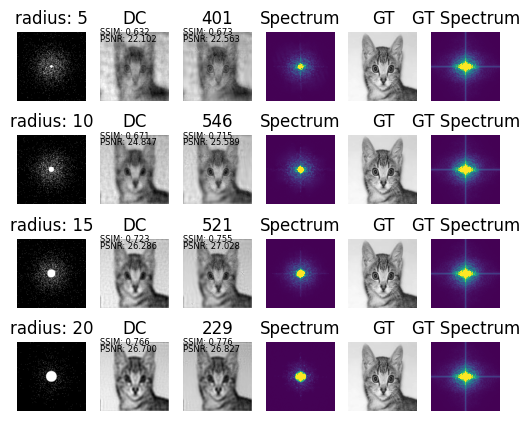

In [36]:
# 加载原始图片
original_image = cv2.imread('/home/b110/code1/xzz/data/cat/测试集1/resized_00001322_020.png', cv2.IMREAD_GRAYSCALE)
# original_image = np.float32(original_image)
# original_image = np.abs(original_image)
# original_image /= np.max(original_image)

# nums = [0, 5, 10]
nums = [5, 10, 15, 20]

fig, ax = plt.subplots(len(nums), 6)

for i in range(len(nums)):
    Mask = scio.loadmat(f'/home/b110/code1/xzz/ncsn2/ncsnpp_ct_small_versioin2/mask/random_mask_3_{nums[i]}_5.mat')['mask']
    # 加载重建图片并计算指标
    reconstructed_images = []
    for j in range(2000):
        image = cv2.imread(f'/home/b110/code1/xzz/ncsn2/ncsnpp_ct_small_versioin2/reconstruct/cat3_{nums[i]}_5/{j}.bmp', cv2.IMREAD_GRAYSCALE)
        # image = np.float32(image)
        # image = np.abs(image)
        # image /= np.max(image)
        reconstructed_images.append(image)
    ssim_scores, psnr_scores = calculate_metrics(original_image, reconstructed_images)
    # 绘制曲线图
    # plot_metrics(ssim_scores, psnr_scores)
    # 找出最好的图片
    best_index_ssim, best_index_psnr = find_best_image(reconstructed_images, ssim_scores, psnr_scores)
    # print(best_index_ssim)
    ax[i][0].imshow(Mask, cmap='gray')
    ax[i][0].set_title(f'radius: {nums[i]}')
    ax[i][0].axis('off')

    # 保真的图像
    dc_fft = np.fft.fft2(original_image)
    dc_fft = np.fft.fftshift(dc_fft)
    dc_fft = dc_fft * Mask
    dc_fft = np.fft.ifftshift(dc_fft)
    dc_p = np.fft.ifft2(dc_fft)
    dc_p = np.abs(dc_p)
    # dc_p /= np.max(dc_p)
    ssim_text = f'SSIM: {ssim(original_image, dc_p):.3f}'
    psnr_text = f'PSNR: {psnr(original_image, dc_p):.3f}'
    ax[i][1].text(0, 10, ssim_text, fontsize=6)
    ax[i][1].text(0, 35, psnr_text, fontsize=6)
    ax[i][1].imshow(dc_p, cmap='gray')
    ax[i][1].set_title(f'DC')
    ax[i][1].axis('off')
    
    # 在图像上标注SSIM和PSNR值
    ssim_text = f'SSIM: {max(ssim_scores):.3f}'
    psnr_text = f'PSNR: {max(psnr_scores):.3f}'
    ax[i][2].text(0, 10, ssim_text, fontsize=6)
    ax[i][2].text(0, 35, psnr_text, fontsize=6)
    ax[i][2].imshow(reconstructed_images[best_index_ssim], cmap='gray')
    ax[i][2].set_title(f"{best_index_ssim}")
    ax[i][2].axis('off')

    ax[i][3].imshow(my_fft(reconstructed_images[best_index_ssim]), vmin=0, vmax=0.002)
    ax[i][3].set_title("Spectrum")
    ax[i][3].axis('off')

    ax[i][4].imshow(original_image, cmap='gray')
    ax[i][4].set_title("GT")
    ax[i][4].axis('off')

    ax[i][5].imshow(my_fft(original_image), vmin=0, vmax=0.002)
    ax[i][5].set_title("GT Spectrum")
    ax[i][5].axis('off')

# fig.suptitle(f'去除保真频谱的图像（第三行）与仅保留保真频谱的图像（第四行）')
# fig.suptitle(f'log2')
plt.subplots_adjust(top=0.90, wspace=0.01, hspace=0.5)
# plt.savefig(f'./result/tmp.jpg')

## 采样率

/home/b110/anaconda3/envs/xzz_ncsn/lib/python3.8/site-packages/skimage/_shared/utils.py:348: UserWarning: Inputs have mismatched dtype.  Setting data_range based on im1.dtype.
  return func(*args, **kwargs)


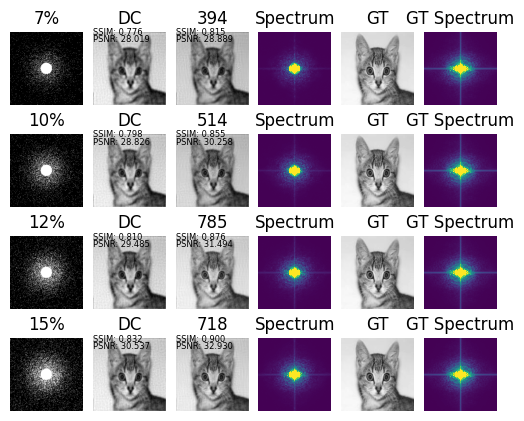

In [34]:
# 加载原始图片
original_image = cv2.imread('/home/b110/code1/xzz/data/cat/测试集1/resized_00001322_020.png', cv2.IMREAD_GRAYSCALE)
# original_image = np.float32(original_image)
# original_image = np.abs(original_image)
# original_image /= np.max(original_image)

# nums = [3, 4, 5, 6]
nums = [7, 10, 12, 15]

fig, ax = plt.subplots(len(nums), 6)

for i in range(len(nums)):
    Mask = scio.loadmat(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/mask/random_mask_{nums[i]}_20_5.mat')['mask']
    # 加载重建图片并计算指标
    reconstructed_images = []
    for j in range(2000):
        image = cv2.imread(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/cat{nums[i]}_20_5/{j}.bmp', cv2.IMREAD_GRAYSCALE)
        # image = np.float32(image)
        # image = np.abs(image)
        # image /= np.max(image)
        reconstructed_images.append(image)
    ssim_scores, psnr_scores = calculate_metrics(original_image, reconstructed_images)
    # 绘制曲线图
    # plot_metrics(ssim_scores, psnr_scores)
    # 找出最好的图片
    best_index_ssim, best_index_psnr = find_best_image(reconstructed_images, ssim_scores, psnr_scores)
    # print(best_index_ssim)
    ax[i][0].imshow(Mask, cmap='gray')
    ax[i][0].set_title(f'{nums[i]}%')
    ax[i][0].axis('off')

    # 保真的图像
    dc_fft = np.fft.fft2(original_image)
    dc_fft = np.fft.fftshift(dc_fft)
    dc_fft = dc_fft * Mask
    dc_fft = np.fft.ifftshift(dc_fft)
    dc_p = np.fft.ifft2(dc_fft)
    dc_p = np.abs(dc_p)
    # dc_p /= np.max(dc_p)
    ssim_text = f'SSIM: {ssim(original_image, dc_p):.3f}'
    psnr_text = f'PSNR: {psnr(original_image, dc_p):.3f}'
    ax[i][1].text(0, 10, ssim_text, fontsize=6)
    ax[i][1].text(0, 35, psnr_text, fontsize=6)
    ax[i][1].imshow(dc_p, cmap='gray')
    ax[i][1].set_title(f'DC')
    ax[i][1].axis('off')
    
    # 在图像上标注SSIM和PSNR值
    ssim_text = f'SSIM: {max(ssim_scores):.3f}'
    psnr_text = f'PSNR: {max(psnr_scores):.3f}'
    ax[i][2].text(0, 10, ssim_text, fontsize=6)
    ax[i][2].text(0, 35, psnr_text, fontsize=6)
    ax[i][2].imshow(reconstructed_images[best_index_ssim], cmap='gray')
    ax[i][2].set_title(f"{best_index_ssim}")
    ax[i][2].axis('off')

    ax[i][3].imshow(my_fft(reconstructed_images[best_index_ssim]), vmin=0, vmax=0.002)
    ax[i][3].set_title("Spectrum")
    ax[i][3].axis('off')

    ax[i][4].imshow(original_image, cmap='gray')
    ax[i][4].set_title("GT")
    ax[i][4].axis('off')

    ax[i][5].imshow(my_fft(original_image), vmin=0, vmax=0.002)
    ax[i][5].set_title("GT Spectrum")
    ax[i][5].axis('off')

# fig.suptitle(f'去除保真频谱的图像（第三行）与仅保留保真频谱的图像（第四行）')
# fig.suptitle(f'log2')
plt.subplots_adjust(top=0.90, wspace=0.01, hspace=0.4)
plt.savefig(f'./result/tmp.jpg')

## 融合两图

(-0.5, 127.5, 127.5, -0.5)

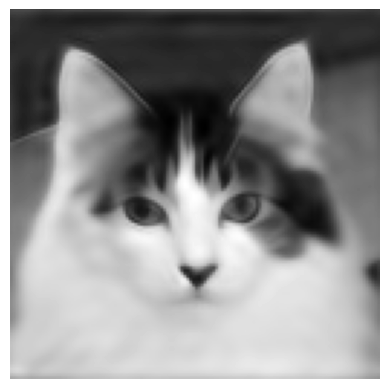

In [3]:
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import scipy.io as scio

# Mask1 = scio.loadmat(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/mask/random_mask_5_5_5.mat')['mask']
# Mask2 = scio.loadmat(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/mask/random_mask_5_20_5.mat')['mask']
image1 = cv2.imread(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/5/152.bmp', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread(f'/home/b110/code1/xzz/ncsn_im/ncsnpp_ct_small_versioin2/reconstruct/5/1330.bmp', cv2.IMREAD_GRAYSCALE)
image1 = np.float32(image1)
image1 = np.abs(image1)
image1 /= np.max(image1)
image2 = np.float32(image2)
image2 = np.abs(image2)
image2 /= np.max(image2)
image = image1 * 0.5 + image2 * 0.5
plt.imshow(image, cmap='gray')
# ax[i][1].set_title(f"{best_index_ssim}")
plt.axis('off')

## ssim和psnr曲线绘制

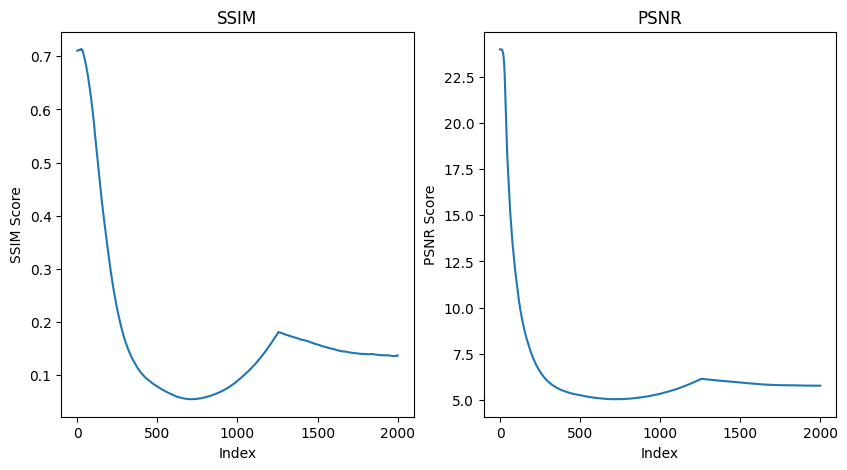

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(original_image, reconstructed_images):
    ssim_scores = []
    psnr_scores = []

    for image in reconstructed_images:
        # 计算 SSIM
        ssim_value = ssim(original_image, image)
        ssim_scores.append(ssim_value)

        # 计算 PSNR
        psnr = cv2.PSNR(original_image, image)
        psnr_scores.append(psnr)

    return ssim_scores, psnr_scores

def plot_metrics(ssim_scores, psnr_scores):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(ssim_scores)
    plt.title('SSIM')
    plt.xlabel('Index')
    plt.ylabel('SSIM Score')

    plt.subplot(1, 2, 2)
    plt.plot(psnr_scores)
    plt.title('PSNR')
    plt.xlabel('Index')
    plt.ylabel('PSNR Score')

    plt.show()

def find_best_image(reconstructed_images, ssim_scores, psnr_scores):
    best_index_ssim = np.argmax(ssim_scores)
    best_index_psnr = np.argmax(psnr_scores)

    best_image_ssim = reconstructed_images[best_index_ssim]
    best_image_psnr = reconstructed_images[best_index_psnr]

    return best_index_ssim

# 加载原始图片
original_image = cv2.imread('/home/b110/code1/xzz/data/afhq/val/cat/flickr_cat_000008.jpg', cv2.IMREAD_GRAYSCALE)
original_image = cv2.resize(original_image, (128, 128))

# 加载重建图片并计算指标
reconstructed_images = []
for i in range(2000):
    image = cv2.imread(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/5_log/{i}.bmp', cv2.IMREAD_GRAYSCALE)
    reconstructed_images.append(image)

ssim_scores, psnr_scores = calculate_metrics(original_image, reconstructed_images)

# 绘制曲线图
plot_metrics(ssim_scores, psnr_scores)

# 找出最好的图片
best_index_ssim = find_best_image(reconstructed_images, ssim_scores, psnr_scores)
# print(best_index_ssim)
# plt.imshow(reconstructed_images[best_index_ssim], cmap='gray')
# plt.axis('off')
# cv2.imwrite('best_image_ssim.bmp', best_image_ssim)
# cv2.imwrite('best_image_psnr.bmp', best_image_psnr)

/tmp/ipykernel_4087359/3638690643.py:8: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img = img.resize((128, 128), Image.ANTIALIAS)


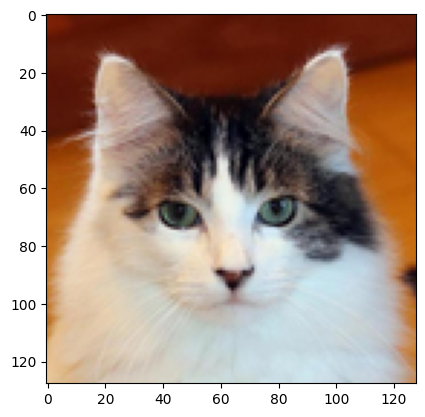

In [10]:
import skimage
import cv2
from PIL import Image
import os
import matplotlib.pyplot as plt
img = Image.open("/home/b110/code1/xzz/data/afhq/val/cat/flickr_cat_000008.jpg")

img = img.resize((128, 128), Image.ANTIALIAS)
plt.imshow(img)

In [2]:
import cv2
import numpy as np
for j in range(2000):
    image = cv2.imread(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/5_log/{j}.bmp', cv2.IMREAD_GRAYSCALE)
    image_k = np.fft.fft2(image)
    image_k = np.fft.fftshift(image_k)
    cv2.imwrite(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/5_log_k/{j}.bmp', np.abs(image_k))

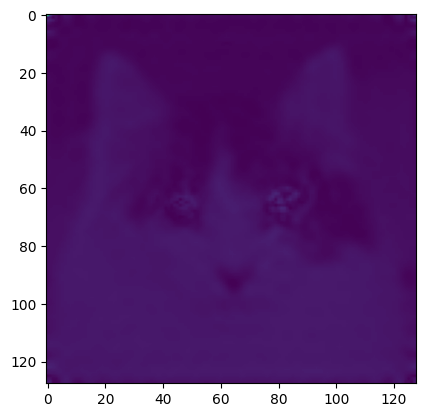

In [11]:
import matplotlib.pyplot as plt
image = cv2.imread(f'/home/b110/code1/xzz/ncsn/ncsnpp_ct_small_versioin2/reconstruct/5_log/500.bmp', cv2.IMREAD_GRAYSCALE)
image_k = np.fft.fft2(image)
image_k = np.fft.fftshift(image_k)
plt.imshow(image)